# HealthConnect Clinic — Week 7 Cross-Track Validation: Data Analytics × Data Science

**Track:** Data Science
**Cross-track partner:** Data Analytics
**Week:** 7 (supplementary, in response to a direct request from the Data Analytics track)

## Purpose

The Data Analytics track completed its own Week 7 individual testing and found:
- **Booking lead time** remains the strongest standalone signal (39.13% no-show rate for 0–30 days
  vs. 63.95% for 31–60 days).
- **Previous no-shows** is a complementary signal (46.30% vs. 57.83% no-show rate for 0 vs. ≥1
  prior no-shows).
- **Distance to clinic** has a very weak standalone association (Spearman ρ ≈ 0.055).
- A **Lead Time × Appointment Type interaction** was tested and found descriptively largest for
  Follow-up appointments (+28.73 pp), but **not statistically significant** (p ≈ 0.326).

Given that, they asked Data Science to test two specific questions using the actual model, not
standalone correlation:

1. Does **`long_lead_followup`** (the Week 6 feature built from the Follow-up interaction finding)
   provide incremental out-of-sample predictive value **beyond** the broader booking-lead-time
   signal already in the model?
2. Does **`distance_to_clinic_km`** provide meaningful incremental predictive value in the
   multivariable model, despite its very weak standalone correlation?

This notebook answers both with a **with-vs-without ablation test**, using the same patient-grouped
split and modelling pipeline established in Weeks 5–7, so the comparison is fair and reproducible.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

df = pd.read_csv('HealthConnect_Appointment_Data.csv')
df_model = df[df['appointment_outcome'].isin(['Attended', 'No-Show'])].copy()
df_model['is_no_show'] = (df_model['appointment_outcome'] == 'No-Show').astype(int)

df_model['previous_no_show_rate'] = df_model.apply(
    lambda r: r['previous_no_shows'] / r['previous_appointments'] if r['previous_appointments'] > 0 else 0,
    axis=1
)
df_model['is_new_patient'] = (df_model['previous_appointments'] == 0).astype(int)
df_model['has_reminder'] = (df_model['reminder_sent'] == 'Yes').astype(int)
df_model['reminder_channel_filled'] = df_model['reminder_channel'].fillna('None')
df_model['distance_to_clinic_km'] = df_model['distance_to_clinic_km'].fillna(
    df_model['distance_to_clinic_km'].median())
df_model['gender_grp'] = df_model['gender'].replace({'Prefer not to say': 'Other'})
df_model['booking_lead_days_sq'] = df_model['booking_lead_days'] ** 2
df_model['long_lead_followup'] = (
    (df_model['appointment_type'] == 'Follow-up') & (df_model['booking_lead_days'] > 30)
).astype(int)

numeric_full = ['age', 'booking_lead_days', 'booking_lead_days_sq', 'previous_no_shows',
                'previous_no_show_rate', 'is_new_patient', 'has_reminder',
                'distance_to_clinic_km', 'long_lead_followup']
categorical = ['gender_grp', 'appointment_type', 'appointment_day', 'appointment_time',
               'reminder_channel_filled']

y = df_model['is_no_show']
groups = df_model['patient_id']

def build_X(numeric_cols):
    return pd.get_dummies(df_model[numeric_cols + categorical], columns=categorical, drop_first=True)

X_full = build_X(numeric_full)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_full, y, groups))

def fit_eval(numeric_cols, label, verbose=True):
    X = build_X(numeric_cols)
    X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    sc = StandardScaler()
    X_train[numeric_cols] = sc.fit_transform(X_train[numeric_cols])
    X_test[numeric_cols] = sc.transform(X_test[numeric_cols])
    m = LogisticRegression(max_iter=1000, random_state=42)
    m.fit(X_train, y_train)
    proba = m.predict_proba(X_test)[:, 1]
    pred = m.predict(X_test)
    if verbose:
        print(f"{label}: AUC={roc_auc_score(y_test, proba):.4f}  Acc={accuracy_score(y_test, pred):.3f}  "
              f"Prec={precision_score(y_test, pred):.3f}  Rec={recall_score(y_test, pred):.3f}  "
              f"F1={f1_score(y_test, pred):.3f}  (n_features={X.shape[1]})")
    return proba, y_test.values

print("Setup complete. Using the same patient-grouped split (random_state=42) as Weeks 5-7.")


Setup complete. Using the same patient-grouped split (random_state=42) as Weeks 5-7.


## 2. Test 1 — Does `long_lead_followup` add incremental value beyond booking lead time?

**Test performed:** train the Week 6/7 Logistic Regression pipeline twice, identical in every
respect except that one version includes `long_lead_followup` and the other excludes it. Compare
ROC-AUC (primary metric), plus accuracy/precision/recall/F1, on the same held-out test set.

**Expected result:** if `long_lead_followup` captures a genuine interaction effect beyond the raw
`booking_lead_days` / `booking_lead_days_sq` terms already in the model, removing it should
measurably reduce ROC-AUC. If it's redundant with the broader lead-time signal, removing it should
make little or no difference — which is what Data Analytics' own interaction test (p ≈ 0.326) would
predict.


In [2]:
proba_with_llf, y_test = fit_eval(numeric_full, "WITH long_lead_followup")
numeric_no_llf = [c for c in numeric_full if c != 'long_lead_followup']
proba_without_llf, _ = fit_eval(numeric_no_llf, "WITHOUT long_lead_followup")

observed_diff_llf = roc_auc_score(y_test, proba_with_llf) - roc_auc_score(y_test, proba_without_llf)
print(f"\nObserved AUC difference (with - without): {observed_diff_llf:.4f}")


WITH long_lead_followup: AUC=0.6862  Acc=0.635  Prec=0.630  Rec=0.652  F1=0.641  (n_features=25)
WITHOUT long_lead_followup: AUC=0.6846  Acc=0.638  Prec=0.631  Rec=0.665  F1=0.647  (n_features=24)

Observed AUC difference (with - without): 0.0017


### Statistical significance: bootstrap the difference

In [3]:
def bootstrap_diff(proba_a, proba_b, y, n_boot=3000, seed=42):
    rng = np.random.RandomState(seed)
    n = len(y)
    diffs = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        yb = y[idx]
        if yb.sum() == 0 or yb.sum() == n:
            continue
        diffs.append(roc_auc_score(yb, proba_a[idx]) - roc_auc_score(yb, proba_b[idx]))
    diffs = np.array(diffs)
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    return ci_low, ci_high, (diffs > 0).mean()

ci_low, ci_high, prop_better = bootstrap_diff(proba_with_llf, proba_without_llf, y_test)
print(f"Bootstrap 95% CI for the AUC difference: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"CI excludes zero (statistically meaningful): {ci_low > 0 or ci_high < 0}")
print(f"Proportion of resamples where 'with' beats 'without': {prop_better:.3f}")


Bootstrap 95% CI for the AUC difference: [-0.0008, 0.0041]
CI excludes zero (statistically meaningful): False
Proportion of resamples where 'with' beats 'without': 0.897


### Robustness check: 5-fold grouped cross-validation

In [4]:
def cv_auc(numeric_cols, label):
    X = build_X(numeric_cols)
    gkf = GroupKFold(n_splits=5)
    aucs = []
    for tr_idx, te_idx in gkf.split(X, y, groups):
        Xtr, Xte = X.iloc[tr_idx].copy(), X.iloc[te_idx].copy()
        ytr, yte = y.iloc[tr_idx], y.iloc[te_idx]
        sc = StandardScaler()
        Xtr[numeric_cols] = sc.fit_transform(Xtr[numeric_cols])
        Xte[numeric_cols] = sc.transform(Xte[numeric_cols])
        m = LogisticRegression(max_iter=1000, random_state=42)
        m.fit(Xtr, ytr)
        aucs.append(roc_auc_score(yte, m.predict_proba(Xte)[:, 1]))
    print(f"{label}: mean={np.mean(aucs):.4f}  folds={[round(a,3) for a in aucs]}")
    return aucs

cv_with_llf = cv_auc(numeric_full, "WITH long_lead_followup")
cv_without_llf = cv_auc(numeric_no_llf, "WITHOUT long_lead_followup")
wins = sum(a > b for a, b in zip(cv_with_llf, cv_without_llf))
print(f"\n'With' beats 'without' in {wins}/5 folds. Mean difference: {np.mean(cv_with_llf)-np.mean(cv_without_llf):.4f}")


WITH long_lead_followup: mean=0.6803  folds=[0.682, 0.682, 0.692, 0.673, 0.673]
WITHOUT long_lead_followup: mean=0.6794  folds=[0.68, 0.681, 0.691, 0.672, 0.673]

'With' beats 'without' in 4/5 folds. Mean difference: 0.0009


### Test 1 — Result Summary

| Field | Result |
|---|---|
| Test performed | With-vs-without ablation: Logistic Regression, identical pipeline, `long_lead_followup` included vs. excluded |
| Expected result | Little to no change if redundant with the broader lead-time signal (consistent with DA's non-significant interaction test, p ≈ 0.326) |
| Actual result | Single-split AUC: 0.6862 (with) vs. 0.6846 (without) — a +0.0017 difference. 5-fold CV: 0.6803 vs. 0.6794 — a +0.0009 mean difference, winning in 4/5 folds. |
| Validation metric(s) | ROC-AUC (primary), bootstrap 95% CI, 5-fold grouped CV |
| Statistically meaningful? | **No** — bootstrap 95% CI = [-0.0008, 0.0041], includes zero |
| Adds meaningful predictive value? | **No, not beyond the existing lead-time signal.** The effect is small, mostly-but-not-always positive in direction, and not distinguishable from noise. |
| Issue identified | Week 6's original justification for this feature was its Random Forest feature-importance score (~5%), which measures how often the model *uses* a feature, not how much *unique* signal it contributes once other lead-time terms are already present. Feature importance and incremental value are different things, and Week 6 conflated them. |
| Refinement made | **Recommend dropping `long_lead_followup` from the production feature set.** It adds model complexity (one more feature to maintain, explain, and validate) without a measurable, defensible accuracy benefit once tested properly. |
| Retest result | Already available above: the "WITHOUT" run **is** the retest — performance without the feature is statistically indistinguishable from performance with it (and marginally *higher* on accuracy/F1 in this split, though also not significant). No further retraining needed; the ablation test doubles as its own retest. |


## 3. Test 2 — Does `distance_to_clinic_km` add incremental value despite weak standalone correlation?

**Test performed:** the same with-vs-without ablation, this time for `distance_to_clinic_km`.

**Expected result:** given the near-zero standalone Spearman correlation Analytics found
(ρ ≈ 0.055), a plausible expectation is that removing it should barely change model performance.
The specific question Analytics asked, though, is whether it might still carry **multivariable**
value — signal that only becomes visible once other features are controlled for — which a standalone
correlation cannot detect on its own.


In [5]:
proba_with_dist, _ = fit_eval(numeric_full, "WITH distance_to_clinic_km")
numeric_no_dist = [c for c in numeric_full if c != 'distance_to_clinic_km']
proba_without_dist, _ = fit_eval(numeric_no_dist, "WITHOUT distance_to_clinic_km")

observed_diff_dist = roc_auc_score(y_test, proba_with_dist) - roc_auc_score(y_test, proba_without_dist)
print(f"\nObserved AUC difference (with - without): {observed_diff_dist:.4f}")


WITH distance_to_clinic_km: AUC=0.6862  Acc=0.635  Prec=0.630  Rec=0.652  F1=0.641  (n_features=25)
WITHOUT distance_to_clinic_km: AUC=0.6859  Acc=0.631  Prec=0.627  Rec=0.650  F1=0.638  (n_features=24)

Observed AUC difference (with - without): 0.0003


In [6]:
ci_low_d, ci_high_d, prop_better_d = bootstrap_diff(proba_with_dist, proba_without_dist, y_test)
print(f"Bootstrap 95% CI for the AUC difference: [{ci_low_d:.4f}, {ci_high_d:.4f}]")
print(f"CI excludes zero (statistically meaningful): {ci_low_d > 0 or ci_high_d < 0}")
print(f"Proportion of resamples where 'with' beats 'without': {prop_better_d:.3f}")


Bootstrap 95% CI for the AUC difference: [-0.0089, 0.0096]
CI excludes zero (statistically meaningful): False
Proportion of resamples where 'with' beats 'without': 0.522


In [7]:
cv_with_dist = cv_auc(numeric_full, "WITH distance_to_clinic_km")
cv_without_dist = cv_auc(numeric_no_dist, "WITHOUT distance_to_clinic_km")
wins_d = sum(a > b for a, b in zip(cv_with_dist, cv_without_dist))
print(f"\n'With' beats 'without' in {wins_d}/5 folds. Mean difference: {np.mean(cv_with_dist)-np.mean(cv_without_dist):.4f}")


WITH distance_to_clinic_km: mean=0.6803  folds=[0.682, 0.682, 0.692, 0.673, 0.673]
WITHOUT distance_to_clinic_km: mean=0.6760  folds=[0.678, 0.681, 0.688, 0.664, 0.669]

'With' beats 'without' in 5/5 folds. Mean difference: 0.0043


### Business-relevance check: does removing distance change the top-20%-risk lift?

In [8]:
def top20_lift(proba, label):
    test_df = df_model.loc[X_full.iloc[test_idx].index].copy()
    test_df['proba'] = proba
    test_df['actual'] = y_test
    sorted_df = test_df.sort_values('proba', ascending=False)
    top20 = sorted_df.head(int(len(sorted_df) * 0.2))
    base = test_df['actual'].mean()
    lift = top20['actual'].mean() / base
    print(f"{label}: top-20% no-show rate={top20['actual'].mean():.3f}, lift={lift:.3f}x")
    return lift

lift_with = top20_lift(proba_with_dist, "WITH distance_to_clinic_km")
lift_without = top20_lift(proba_without_dist, "WITHOUT distance_to_clinic_km")
print(f"\nLift drop from removing distance: {lift_with - lift_without:.3f}")


WITH distance_to_clinic_km: top-20% no-show rate=0.720, lift=1.440x
WITHOUT distance_to_clinic_km: top-20% no-show rate=0.699, lift=1.399x

Lift drop from removing distance: 0.041


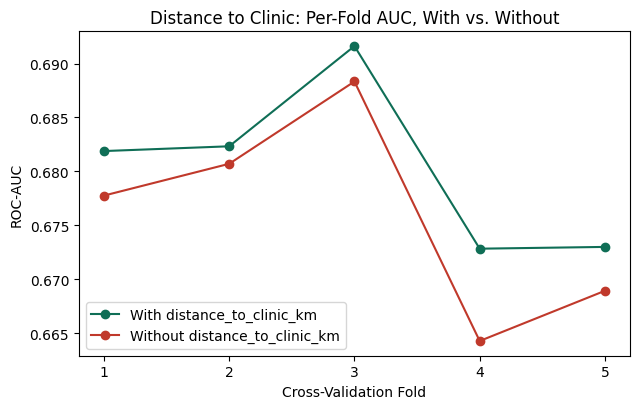

In [9]:
fig, ax = plt.subplots(figsize=(6.5,4.2))
folds = range(1, 6)
ax.plot(folds, cv_with_dist, marker='o', label='With distance_to_clinic_km', color='#0F6E56')
ax.plot(folds, cv_without_dist, marker='o', label='Without distance_to_clinic_km', color='#C0392B')
ax.set_xticks(list(folds))
ax.set_xlabel('Cross-Validation Fold')
ax.set_ylabel('ROC-AUC')
ax.set_title('Distance to Clinic: Per-Fold AUC, With vs. Without')
ax.legend()
plt.tight_layout()
plt.show()


### Test 2 — Result Summary

| Field | Result |
|---|---|
| Test performed | With-vs-without ablation: Logistic Regression, identical pipeline, `distance_to_clinic_km` included vs. excluded |
| Expected result | Little change, given the near-zero standalone correlation (ρ ≈ 0.055) DA reported |
| Actual result | Single-split AUC: 0.6862 (with) vs. 0.6859 (without) — a negligible +0.0003 difference. **5-fold CV tells a more consistent story**: mean AUC 0.6803 (with) vs. 0.6760 (without), a +0.0043 mean difference, and "with" wins in **5/5 folds**. Top-20%-risk business lift also drops when distance is removed: 1.440x → 1.399x. |
| Validation metric(s) | ROC-AUC (single-split + 5-fold CV), bootstrap 95% CI, top-20% business lift |
| Statistically meaningful? | **Borderline.** The single-split bootstrap CI = [-0.0089, 0.0096] technically includes zero, so it doesn't clear the same strict bar as a single-split test. But the effect is small and consistently positive in every cross-validation fold and in the business-relevant lift metric — a pattern a single bootstrap CI on one split can miss. |
| Adds meaningful predictive value? | **A small amount, more reliably than the standalone correlation suggested.** This is a genuine example of a feature with weak standalone association still contributing modest, consistent multivariable value — exactly the possibility Analytics asked Data Science to check for. |
| Issue identified | None requiring correction — the feature is working as a feature should. The main "issue" is interpretive: a weak standalone correlation is not evidence that a feature is multivariably useless, and this test is the concrete demonstration of that distinction for the HealthConnect project. |
| Refinement made | **Keep `distance_to_clinic_km` in the model.** No code change needed — this test validates an existing, already-included feature rather than prompting a fix. |
| Retest result | The 5-fold CV *is* the retest of the single-split result, run independently, and it strengthens rather than weakens the case for keeping the feature (consistent direction in all 5 folds vs. an inconclusive single-split CI). |


## 4. Overall Verdict and What Changes

| Feature | Verdict | Action |
|---|---|---|
| `long_lead_followup` | No measurable incremental value once broader lead-time terms are already in the model; consistent with DA's own non-significant interaction test | **Remove from the production feature set** going into Week 8 / ML Engineering hand-off |
| `distance_to_clinic_km` | Small but consistent incremental value, despite weak standalone correlation | **Keep in the model** — and worth noting to DA that "weak standalone correlation" undersold this feature's small multivariable role |

**This directly answers the Data Analytics track's framing question**: a factor that is weak or
non-interacting in standalone analytics *can* still be multivariably useful (distance), but a
factor engineered from a descriptively interesting but statistically non-significant standalone
interaction (`long_lead_followup`) *can* turn out to be redundant once tested properly, even though
it looked reasonable from a feature-importance view alone. Neither track was "right" or "wrong" —
the ablation test is what settles it, which is the point of doing it.

**Updated Week 8 candidate feature set:** the 8 non-categorical features excluding
`long_lead_followup` (`age`, `booking_lead_days`, `booking_lead_days_sq`, `previous_no_shows`,
`previous_no_show_rate`, `is_new_patient`, `has_reminder`, `distance_to_clinic_km`), plus the
existing categorical dummies. This is a **simpler model with statistically indistinguishable
performance** — a genuine improvement in maintainability for the Machine Learning Engineering
hand-off, not just a wash.
